In [ ]:
import os
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [49]:
!nvidia-smi

Fri Dec 26 00:06:24 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:23:00.0  On |                  N/A |
|  0%   39C    P3             20W /  165W |   11249MiB /  16380MiB |     19%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:

DATASET_PATH = "./tr_signLanguage_dataset"


print("Dataset klasörü bulundu mu?:", os.path.exists(DATASET_PATH))
print("İçindeki klasörler:")
print(os.listdir(DATASET_PATH))

Dataset klasörü bulundu mu?: True
İçindeki klasörler:
['test', 'train']


In [6]:
train_path = os.path.join(DATASET_PATH, "train")
test_path  = os.path.join(DATASET_PATH, "test")

train_classes = os.listdir(train_path)
test_classes = os.listdir(test_path)

print("Train klasöründeki sınıf sayısı:", len(train_classes))
print("Test klasöründeki sınıf sayısı :", len(test_classes))

print("\nTrain sınıfları:")
print(train_classes)

print("\nTest sınıfları:")
print(test_classes)


Train klasöründeki sınıf sayısı: 26
Test klasöründeki sınıf sayısı : 26

Train sınıfları:
['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'R', 'S', 'space', 'T', 'U', 'V', 'Y', 'Z']

Test sınıfları:
['A', 'B', 'C', 'D', 'del', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'R', 'S', 'space', 'T', 'U', 'V', 'Y', 'Z']


In [7]:
train_counts = defaultdict(int)
test_counts = defaultdict(int)

for cls in train_classes:
    train_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))


for cls in test_classes:
    test_counts[cls] = len(os.listdir(os.path.join(test_path, cls)))


print(" Train örnek dağılımı:")
for k,v in train_counts.items():
    print(f"{k}: {v}")

print("\n Test örnek dağılımı:")
for k,v in test_counts.items():
    print(f"{k}: {v}")

print("\nToplam Train Görsel:", sum(train_counts.values()))
print("Toplam Test Görsel :", sum(test_counts.values()))
print("Toplam Görsel     :", sum(train_counts.values()) + sum(test_counts.values()))


 Train örnek dağılımı:
A: 4800
B: 4800
C: 4800
D: 4800
del: 3000
E: 4800
F: 4800
G: 4800
H: 4800
I: 4800
J: 4800
K: 4800
L: 4800
M: 4800
N: 4800
nothing: 3000
O: 4800
P: 4800
R: 4800
S: 4800
space: 3000
T: 4800
U: 4800
V: 4800
Y: 4800
Z: 4800

 Test örnek dağılımı:
A: 1952
B: 1929
C: 1953
D: 1948
del: 1000
E: 1943
F: 1973
G: 1947
H: 1952
I: 1933
J: 1944
K: 1950
L: 1958
M: 1934
N: 1941
nothing: 1000
O: 1945
P: 1953
R: 1936
S: 1956
space: 1000
T: 1958
U: 1925
V: 1946
Y: 1953
Z: 1957

Toplam Train Görsel: 119400
Toplam Test Görsel : 47786
Toplam Görsel     : 167186


PreProcess İşlemleri

In [9]:
IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),  # Augmentation
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])



train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
test_dataset  = datasets.ImageFolder(test_path, transform=test_transform)


train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(train_dataset, [train_size, val_size])


BATCH_SIZE = 64  

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


class_names = train_dataset.classes

print("Train set:", len(train_data), "görüntü")
print("Val set  :", len(val_data), "görüntü")
print("Test set :", len(test_dataset), "görüntü")
print("\nSınıflar:", class_names)
print("\n DataLoader'lar başarıyla hazırlandı.")


Train set: 95520 görüntü
Val set  : 23880 görüntü
Test set : 47786 görüntü

Sınıflar: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']

 DataLoader'lar başarıyla hazırlandı.


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)


Kullanılan cihaz: cuda


In [12]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_one_epoch(model, dataloader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc



def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 
               'train_acc': [], 'val_acc': []}

    model.to(device)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return history


In [13]:
vgg16 = models.vgg16(pretrained=True)


vgg16.classifier[6] = nn.Linear(4096, len(class_names))

vgg16 = vgg16.to(device)

print(vgg16)  # Model yapısını görmek için
print("\n VGG16 hazir")


c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Berkay/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:49<00:00, 11.2MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.parameters(), lr=0.0005)  # şimdilik varsayılan LR


history = train_model(
    model=vgg16,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=5  # sadece test amaçlı
)

print("\n Kısa test eğitimi tamamlandı")


Epoch [1/5] | Train Loss: 0.6568 | Val Loss: 0.1371 | Train Acc: 0.7904 | Val Acc: 0.9593
Epoch [2/5] | Train Loss: 0.1683 | Val Loss: 0.0864 | Train Acc: 0.9545 | Val Acc: 0.9762
Epoch [3/5] | Train Loss: 0.1241 | Val Loss: 0.1545 | Train Acc: 0.9678 | Val Acc: 0.9634
Epoch [4/5] | Train Loss: 0.1305 | Val Loss: 0.1168 | Train Acc: 0.9680 | Val Acc: 0.9728
Epoch [5/5] | Train Loss: 0.1095 | Val Loss: 0.0647 | Train Acc: 0.9733 | Val Acc: 0.9832

 Kısa test eğitimi tamamlandı


VGG 16 HİPERPARAMETRE TUNİNG

In [15]:
from copy import deepcopy


vgg_configs = [
    {"lr": 0.001,  "batch": 64,  "opt": "adam", "dropout": 0.5, "freeze": True},
    {"lr": 0.0005, "batch": 64,  "opt": "adam", "dropout": 0.5, "freeze": True},
    {"lr": 0.0003, "batch": 128, "opt": "adam", "dropout": 0.5, "freeze": True},
    {"lr": 0.0005, "batch": 64,  "opt": "sgd",  "dropout": 0.5, "freeze": True},
    {"lr": 0.0005, "batch": 64,  "opt": "adam", "dropout": 0.3, "freeze": True}
]

results = []

def build_vgg(dropout, freeze):
    model = models.vgg16(pretrained=True)
    if freeze:
        for param in model.features.parameters():
            param.requires_grad = False  # feature extractor freeze
    model.classifier[6] = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(4096, len(class_names))
    )
    return model.to(device)

def get_optimizer(model, opt, lr):
    if opt == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    if opt == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError("Optimizer seçeneği yanlis")

criterion = nn.CrossEntropyLoss()

for i, cfg in enumerate(vgg_configs, start=1):
    print(f"\n============== VGG16 Tuning {i}/5 ==============")
    print(cfg)

    
    train_loader = DataLoader(train_data, batch_size=cfg["batch"], shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_data, batch_size=cfg["batch"], shuffle=False, num_workers=2)

    model = build_vgg(cfg["dropout"], cfg["freeze"])
    optimizer = get_optimizer(model, cfg["opt"], cfg["lr"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=3  # kısa test (her config 3 epoch)
    )

    val_acc = max(history["val_acc"]) # en iyi doğruluk
    results.append((cfg, val_acc))

print("\n==================== Tunıng Sonuçları ====================")
for r in results:
    print(r)



============== VGG16 Tuning 1/5 ==============
{'lr': 0.001, 'batch': 64, 'opt': 'adam', 'dropout': 0.5, 'freeze': True}


c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/3] | Train Loss: 1.5956 | Val Loss: 0.4409 | Train Acc: 0.5968 | Val Acc: 0.8852
Epoch [2/3] | Train Loss: 1.0538 | Val Loss: 0.3975 | Train Acc: 0.7573 | Val Acc: 0.9124
Epoch [3/3] | Train Loss: 0.9103 | Val Loss: 0.3279 | Train Acc: 0.7994 | Val Acc: 0.9255

============== VGG16 Tuning 2/5 ==============
{'lr': 0.0005, 'batch': 64, 'opt': 'adam', 'dropout': 0.5, 'freeze': True}
Epoch [1/3] | Train Loss: 0.8620 | Val Loss: 0.1870 | Train Acc: 0.7473 | Val Acc: 0.9433
Epoch [2/3] | Train Loss: 0.5183 | Val Loss: 0.1250 | Train Acc: 0.8753 | Val Acc: 0.9631
Epoch [3/3] | Train Loss: 0.4457 | Val Loss: 0.1005 | Train Acc: 0.9021 | Val Acc: 0.9696

============== VGG16 Tuning 3/5 ==============
{'lr': 0.0003, 'batch': 128, 'opt': 'adam', 'dropout': 0.5, 'freeze': True}
Epoch [1/3] | Train Loss: 0.5723 | Val Loss: 0.1141 | Train Acc: 0.8154 | Val Acc: 0.9649
Epoch [2/3] | Train Loss: 0.1979 | Val Loss: 0.0726 | Train Acc: 0.9368 | Val Acc: 0.9757
Epoch [3/3] | Train Loss: 0.1599 

In [16]:
def build_vgg_for_final(dropout=0.5, freeze=True):
    model = models.vgg16(pretrained=True)
    if freeze:
        for param in model.features.parameters():
            param.requires_grad = False  
    model.classifier[6] = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(4096, len(class_names))
    )
    return model.to(device)

best_vgg = build_vgg_for_final(dropout=0.5, freeze=True)


optimizer = optim.Adam(best_vgg.parameters(), lr=0.0003)
criterion = nn.CrossEntropyLoss()


train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=2)


final_epochs = 12

vgg16_history_final = train_model(
    model=best_vgg,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=final_epochs
)

print("\n VGG16 final eğitim (freeze=True) tamamlandi")


Epoch [1/12] | Train Loss: 0.5859 | Val Loss: 0.1204 | Train Acc: 0.8112 | Val Acc: 0.9613
Epoch [2/12] | Train Loss: 0.1909 | Val Loss: 0.0668 | Train Acc: 0.9383 | Val Acc: 0.9785
Epoch [3/12] | Train Loss: 0.1555 | Val Loss: 0.0597 | Train Acc: 0.9526 | Val Acc: 0.9804
Epoch [4/12] | Train Loss: 0.1472 | Val Loss: 0.0559 | Train Acc: 0.9579 | Val Acc: 0.9833
Epoch [5/12] | Train Loss: 0.1412 | Val Loss: 0.0467 | Train Acc: 0.9624 | Val Acc: 0.9854
Epoch [6/12] | Train Loss: 0.1198 | Val Loss: 0.0454 | Train Acc: 0.9682 | Val Acc: 0.9865
Epoch [7/12] | Train Loss: 0.1179 | Val Loss: 0.0356 | Train Acc: 0.9697 | Val Acc: 0.9890
Epoch [8/12] | Train Loss: 0.1243 | Val Loss: 0.0359 | Train Acc: 0.9699 | Val Acc: 0.9898
Epoch [9/12] | Train Loss: 0.1282 | Val Loss: 0.0409 | Train Acc: 0.9714 | Val Acc: 0.9898
Epoch [10/12] | Train Loss: 0.1222 | Val Loss: 0.0301 | Train Acc: 0.9737 | Val Acc: 0.9915
Epoch [11/12] | Train Loss: 0.1210 | Val Loss: 0.0298 | Train Acc: 0.9749 | Val Acc: 0.99

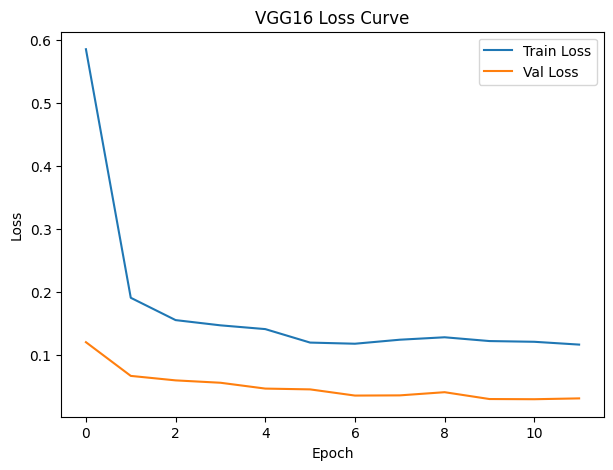

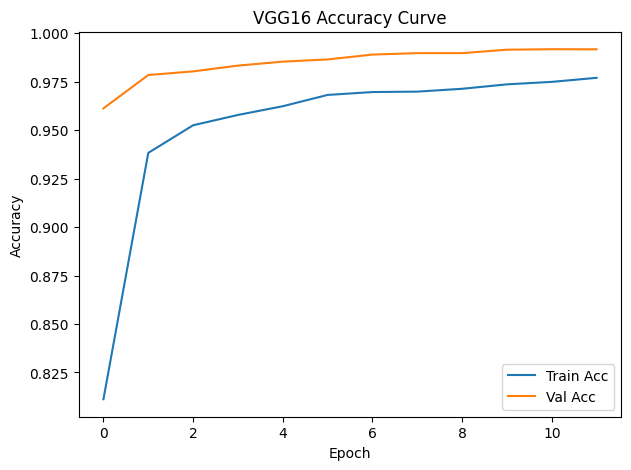

In [17]:
plt.figure(figsize=(7,5))
plt.plot(vgg16_history_final['train_loss'], label="Train Loss")
plt.plot(vgg16_history_final['val_loss'], label="Val Loss")
plt.title("VGG16 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


plt.figure(figsize=(7,5))
plt.plot(vgg16_history_final['train_acc'], label="Train Acc")
plt.plot(vgg16_history_final['val_acc'], label="Val Acc")
plt.title("VGG16 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
dataset_dir = "tr_signLanguage_dataset"
train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
)

test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)
print(" Test DataLoader Hazir")
print("Sınıf sayısı:", len(test_data.classes))
print("Sınıflar:", test_data.classes)


 Test DataLoader Hazir
Sınıf sayısı: 26
Sınıflar: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']


In [21]:
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)

best_vgg.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_vgg(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


overall_acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy: {overall_acc*100:.2f}%\n")


print("\n CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=class_names))



 Test Accuracy: 99.25%


 CLASSIFICATION REPORT

              precision    recall  f1-score   support

           A       0.99      0.99      0.99      1952
           B       1.00      1.00      1.00      1929
           C       0.99      0.99      0.99      1953
           D       0.99      0.99      0.99      1948
           E       1.00      1.00      1.00      1943
           F       1.00      0.99      1.00      1973
           G       0.99      0.99      0.99      1947
           H       0.99      0.99      0.99      1952
           I       0.99      1.00      1.00      1933
           J       1.00      0.98      0.99      1944
           K       1.00      0.99      1.00      1950
           L       0.99      0.99      0.99      1958
           M       0.96      0.98      0.97      1934
           N       0.97      0.96      0.97      1941
           O       0.99      0.99      0.99      1945
           P       1.00      1.00      1.00      1953
           R       0.99      1.

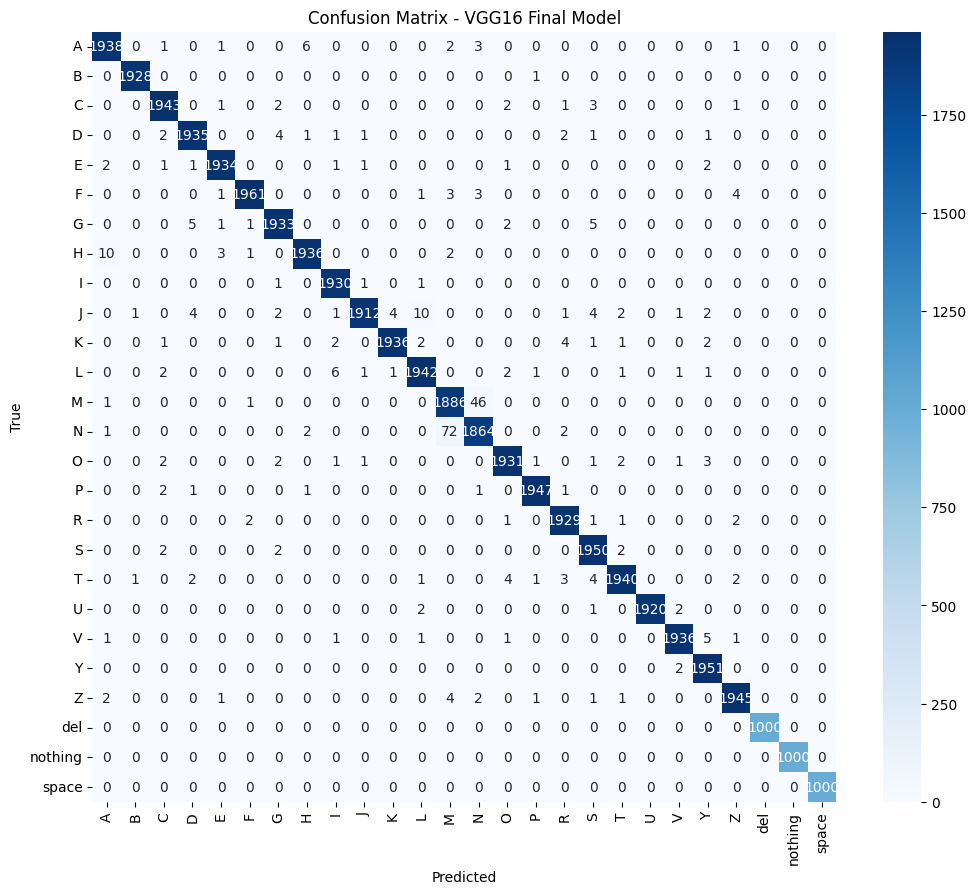

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - VGG16 Final Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [25]:
for param in best_vgg.features.parameters():
    param.requires_grad = True   


optimizer = optim.Adam(best_vgg.parameters(), lr=0.0001)


ft_epochs = 3

vgg16_history_ft = train_model(
    model=best_vgg,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=ft_epochs
)

print("\n Fine-Tuning tamamlandi!")


Epoch [1/3] | Train Loss: 0.1243 | Val Loss: 0.0299 | Train Acc: 0.9681 | Val Acc: 0.9919
Epoch [2/3] | Train Loss: 0.0516 | Val Loss: 0.0542 | Train Acc: 0.9860 | Val Acc: 0.9845
Epoch [3/3] | Train Loss: 0.0365 | Val Loss: 0.0232 | Train Acc: 0.9898 | Val Acc: 0.9932

 Fine-Tuning tamamlandi!


In [26]:
best_vgg.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_vgg(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

overall_acc = accuracy_score(y_true, y_pred)
print(f"\n FINAL TEST ACCURACY (Fine-Tuned): {overall_acc*100:.2f}%\n")

print("\n FINAL CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=test_data.classes))



 FINAL TEST ACCURACY (Fine-Tuned): 99.39%


 FINAL CLASSIFICATION REPORT

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      0.99      0.99      1929
           C       1.00      1.00      1.00      1953
           D       1.00      0.97      0.99      1948
           E       0.99      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       0.98      1.00      0.99      1947
           H       1.00      1.00      1.00      1952
           I       0.99      1.00      1.00      1933
           J       1.00      0.99      0.99      1944
           K       0.99      1.00      1.00      1950
           L       0.99      1.00      0.99      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.96      0.98      1941
           O       1.00      0.99      0.99      1945
           P       1.00      1.00      1.00      1953
      

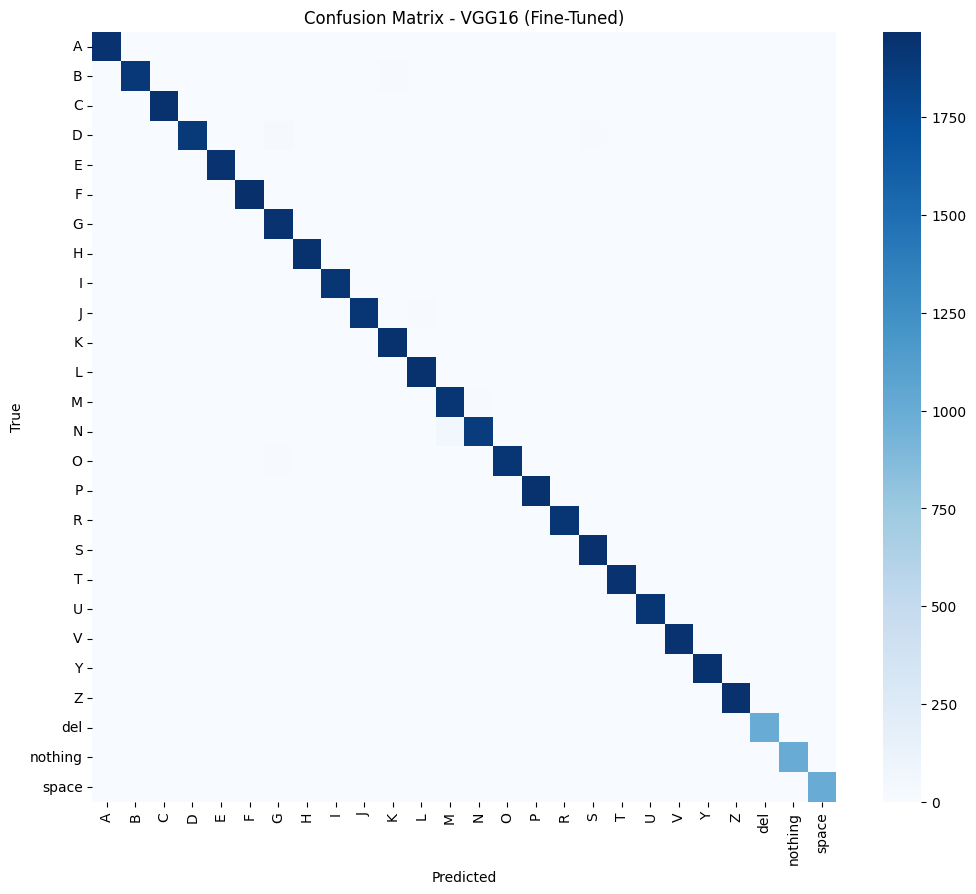

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=test_data.classes,
    yticklabels=test_data.classes
)
plt.title("Confusion Matrix - VGG16 (Fine-Tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Resnet 50 modelinin eğitilmesi 

In [28]:
from torchvision.models import resnet50, ResNet50_Weights

resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)


for param in resnet.parameters():
    param.requires_grad = False


num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, len(class_names))
)

resnet = resnet.to(device)

print(" ResNet50 yüklendi ve 26 sınıfa göre düzenlendi")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Berkay/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:09<00:00, 10.9MB/s]


 ResNet50 yüklendi ve 26 sınıfa göre düzenlendi


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=0.0005)  

print(" ResNet50 sanity-check train başlıyor")

resnet_history_test = train_model(
    model=resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=3
)

print("\n ResNet50 kısa test eğitimi tamamlandi!")


 ResNet50 sanity-check train başlıyor
Epoch [1/3] | Train Loss: 1.1088 | Val Loss: 0.5916 | Train Acc: 0.6992 | Val Acc: 0.8482
Epoch [2/3] | Train Loss: 0.6648 | Val Loss: 0.4573 | Train Acc: 0.7974 | Val Acc: 0.8732
Epoch [3/3] | Train Loss: 0.5970 | Val Loss: 0.4012 | Train Acc: 0.8107 | Val Acc: 0.8862

 ResNet50 kısa test eğitimi tamamlandi!


In [30]:
resnet_configs = [
    {"lr": 0.001,  "batch": 64, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "adam"},
    {"lr": 0.0003, "batch": 128, "opt": "adam"},
    {"lr": 0.0005, "batch": 64, "opt": "sgd"}
]

results_resnet = []

def build_resnet(dropout=0.5, freeze=True):
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, len(class_names))
    )
    return model.to(device)

def get_opt(model, lr, opt):
    if opt == "adam": return optim.Adam(model.fc.parameters(), lr=lr)
    if opt == "sgd":  return optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9)

for i, cfg in enumerate(resnet_configs, start=1):
    print(f"\n============== ResNet50 Tuning {i}/4 ==============")
    print(cfg)

    train_loader = DataLoader(train_data, batch_size=cfg["batch"], shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_data, batch_size=cfg["batch"], shuffle=False, num_workers=2)

    model = build_resnet(dropout=0.5, freeze=True)
    optimizer = get_opt(model, cfg["lr"], cfg["opt"])

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=3
    )

    best_val_acc = max(history["val_acc"])
    results_resnet.append((cfg, best_val_acc))

print("\n==================== ResNet50 Tuning Sonuçları ====================")
for r in results_resnet:
    print(r)



============== ResNet50 Tuning 1/4 ==============
{'lr': 0.001, 'batch': 64, 'opt': 'adam'}
Epoch [1/3] | Train Loss: 0.8970 | Val Loss: 0.4381 | Train Acc: 0.7285 | Val Acc: 0.8685
Epoch [2/3] | Train Loss: 0.6733 | Val Loss: 0.3783 | Train Acc: 0.7821 | Val Acc: 0.8776
Epoch [3/3] | Train Loss: 0.6613 | Val Loss: 0.3393 | Train Acc: 0.7871 | Val Acc: 0.8891

============== ResNet50 Tuning 2/4 ==============
{'lr': 0.0005, 'batch': 64, 'opt': 'adam'}
Epoch [1/3] | Train Loss: 1.0136 | Val Loss: 0.5147 | Train Acc: 0.7138 | Val Acc: 0.8611
Epoch [2/3] | Train Loss: 0.6581 | Val Loss: 0.4173 | Train Acc: 0.7909 | Val Acc: 0.8773
Epoch [3/3] | Train Loss: 0.6146 | Val Loss: 0.3654 | Train Acc: 0.8012 | Val Acc: 0.8909

============== ResNet50 Tuning 3/4 ==============
{'lr': 0.0003, 'batch': 128, 'opt': 'adam'}
Epoch [1/3] | Train Loss: 1.3199 | Val Loss: 0.7277 | Train Acc: 0.6582 | Val Acc: 0.8206
Epoch [2/3] | Train Loss: 0.7470 | Val Loss: 0.5360 | Train Acc: 0.7832 | Val Acc: 0.859

In [31]:
resnet_final = build_resnet(dropout=0.5, freeze=True)

optimizer = optim.Adam(resnet_final.fc.parameters(), lr=0.0005)   # tuning sonucu
criterion = nn.CrossEntropyLoss()


train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=2)

print(" ResNet50 Final eğitim başlıyor...")

resnet_history_final = train_model(
    model=resnet_final,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10
)

print("\n ResNet50 final eğitim tamamlandi")

 ResNet50 Final eğitim başlıyor...
Epoch [1/10] | Train Loss: 1.0154 | Val Loss: 0.5287 | Train Acc: 0.7134 | Val Acc: 0.8553
Epoch [2/10] | Train Loss: 0.6586 | Val Loss: 0.4124 | Train Acc: 0.7919 | Val Acc: 0.8801
Epoch [3/10] | Train Loss: 0.6131 | Val Loss: 0.3765 | Train Acc: 0.8018 | Val Acc: 0.8861
Epoch [4/10] | Train Loss: 0.5974 | Val Loss: 0.3444 | Train Acc: 0.8055 | Val Acc: 0.8957
Epoch [5/10] | Train Loss: 0.5882 | Val Loss: 0.3240 | Train Acc: 0.8077 | Val Acc: 0.8992
Epoch [6/10] | Train Loss: 0.5812 | Val Loss: 0.3158 | Train Acc: 0.8090 | Val Acc: 0.9008
Epoch [7/10] | Train Loss: 0.5865 | Val Loss: 0.3042 | Train Acc: 0.8076 | Val Acc: 0.9057
Epoch [8/10] | Train Loss: 0.5858 | Val Loss: 0.3029 | Train Acc: 0.8092 | Val Acc: 0.9050
Epoch [9/10] | Train Loss: 0.5819 | Val Loss: 0.3050 | Train Acc: 0.8101 | Val Acc: 0.9021
Epoch [10/10] | Train Loss: 0.5815 | Val Loss: 0.2959 | Train Acc: 0.8085 | Val Acc: 0.9057

 ResNet50 final eğitim tamamlandi


In [32]:
for param in resnet_final.parameters():
    param.requires_grad = True  

optimizer = optim.Adam(resnet_final.parameters(), lr=0.0001)  
ft_epochs = 3

print("Fine-tuning başlıyor")

resnet_history_ft = train_model(
    model=resnet_final,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=ft_epochs
)

print("\n Fine-Tuning tamamlandi")


Fine-tuning başlıyor
Epoch [1/3] | Train Loss: 0.0697 | Val Loss: 0.0186 | Train Acc: 0.9774 | Val Acc: 0.9941
Epoch [2/3] | Train Loss: 0.0266 | Val Loss: 0.0307 | Train Acc: 0.9917 | Val Acc: 0.9909
Epoch [3/3] | Train Loss: 0.0222 | Val Loss: 0.0150 | Train Acc: 0.9939 | Val Acc: 0.9959

 Fine-Tuning tamamlandi


In [33]:
resnet_final.eval()
y_true_res = []
y_pred_res = []

with torch.no_grad():
    for images, labels in test_loader:  
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_final(images)
        _, preds = torch.max(outputs, 1)

        y_true_res.extend(labels.cpu().numpy())
        y_pred_res.extend(preds.cpu().numpy())

resnet_test_acc = accuracy_score(y_true_res, y_pred_res)
print(f"\n ResNet50 FINAL TEST ACCURACY (Fine-Tuned): {resnet_test_acc*100:.2f}%\n")

print("\n ResNet50 FINAL CLASSIFICATION REPORT\n")
print(classification_report(y_true_res, y_pred_res, target_names=test_data.classes))



 ResNet50 FINAL TEST ACCURACY (Fine-Tuned): 99.55%


 ResNet50 FINAL CLASSIFICATION REPORT

              precision    recall  f1-score   support

           A       0.99      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      0.99      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      0.99      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.97      0.98      1941
           O       1.00      1.00      1.00      1945
           P       1.00      1.00      1.0

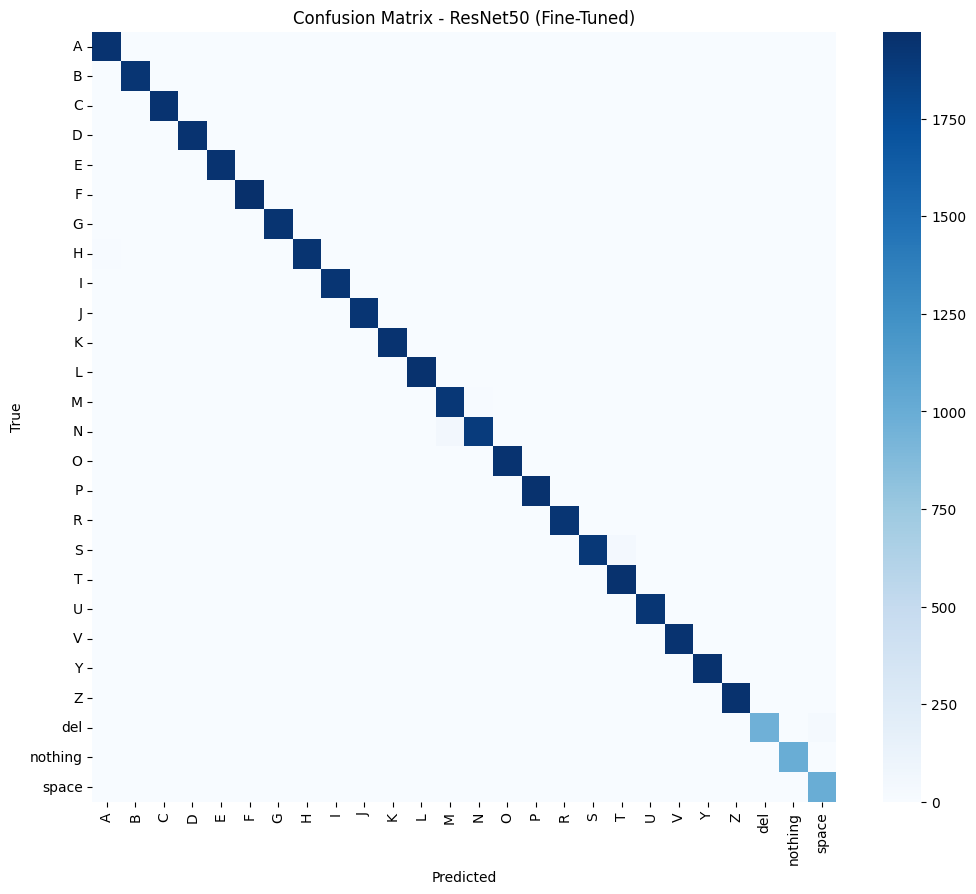

In [34]:
cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_res,
    annot=False,
    cmap="Blues",
    xticklabels=test_data.classes,
    yticklabels=test_data.classes
)
plt.title("Confusion Matrix - ResNet50 (Fine-Tuned)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


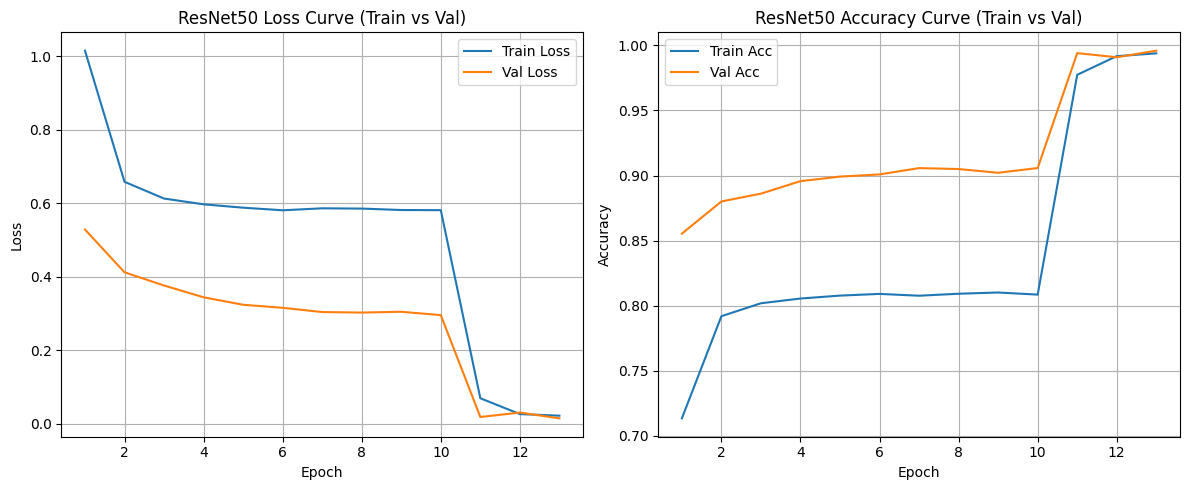

In [36]:
train_loss_res = resnet_history_final['train_loss'] + resnet_history_ft['train_loss']
val_loss_res   = resnet_history_final['val_loss']   + resnet_history_ft['val_loss']
train_acc_res  = resnet_history_final['train_acc']  + resnet_history_ft['train_acc']
val_acc_res    = resnet_history_final['val_acc']    + resnet_history_ft['val_acc']

epochs = range(1, len(train_loss_res)+1)

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(epochs, train_loss_res, label='Train Loss')
plt.plot(epochs, val_loss_res, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss Curve (Train vs Val)")
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs, train_acc_res, label='Train Acc')
plt.plot(epochs, val_acc_res, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy Curve (Train vs Val)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
results = {
    "Model":      ["LeNet-5", "VGG16", "ResNet50"],
    "LR":         ["-", "0.0003", "0.0005"],
    "Batch":      ["-", "128", "64"],
    "Optimizer":  ["-", "Adam", "Adam"],
    "Freeze":     ["Yok", "Var", "Var"],
    "Fine-Tune":  ["Yok", "Var (+3 ep)", "Var (+3 ep)"],
    "Test Acc (%)": ["vize değeri", "99.39", "99.55"],
    "Macro F1":   ["vize", "0.9935", "0.9951"]
}

df = pd.DataFrame(results)
print("\n Model Karşılaştırma Tablosu\n")
print(df.to_string(index=False))


df.to_csv("model_karsilastirma_tablosu.csv", index=False)



 Model Karşılaştırma Tablosu

   Model     LR Batch Optimizer Freeze   Fine-Tune Test Acc (%) Macro F1
 LeNet-5      -     -         -    Yok         Yok  vize değeri     vize
   VGG16 0.0003   128      Adam    Var Var (+3 ep)        99.39   0.9935
ResNet50 0.0005    64      Adam    Var Var (+3 ep)        99.55   0.9951


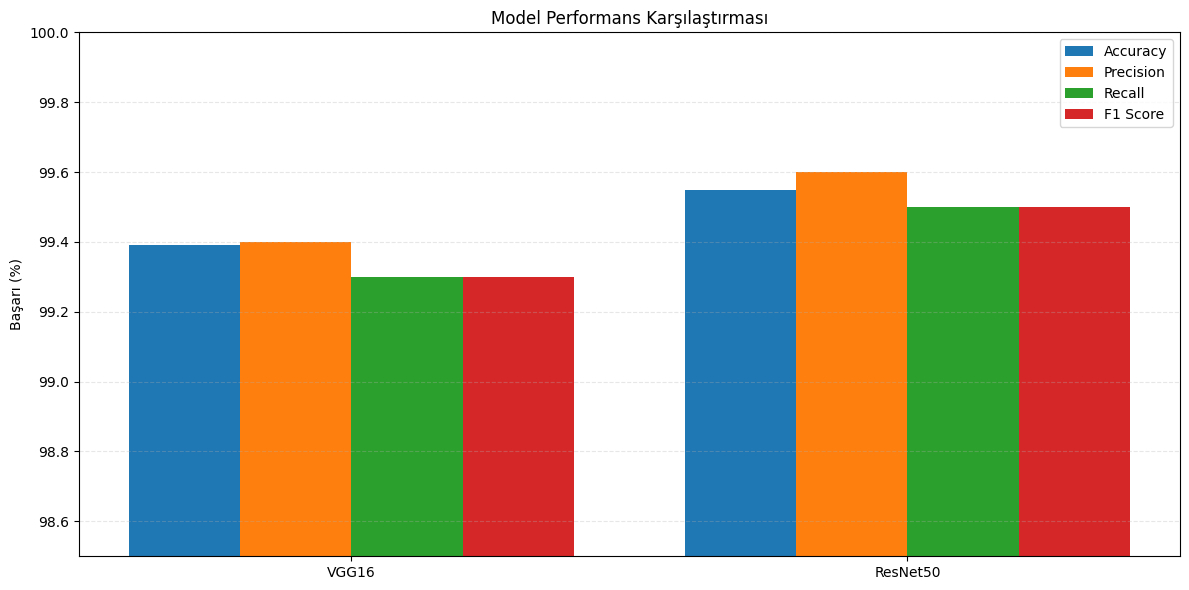

 'model_comparison.png' kaydedildi.


In [48]:
models = ["VGG16", "ResNet50"]

accuracy  = [99.39, 99.55]
precision = [99.4, 99.6]
recall    = [99.3, 99.5]
f1_score  = [99.3, 99.5]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))
plt.bar(x - width*1.5, accuracy,  width, label="Accuracy",  color="#1f77b4")
plt.bar(x - width/2,   precision, width, label="Precision", color="#ff7f0e")
plt.bar(x + width/2,   recall,    width, label="Recall",    color="#2ca02c")
plt.bar(x + width*1.5, f1_score,  width, label="F1 Score",  color="#d62728")

plt.ylabel("Başarı (%)")
plt.title("Model Performans Karşılaştırması")
plt.xticks(x, models)
plt.ylim(98.5, 100)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

print(" 'model_comparison.png' kaydedildi.")


In [40]:
torch.save(best_vgg.state_dict(), "VGG16_final_model.pth")
torch.save(resnet_final.state_dict(), "ResNet50_final_model.pth")


In [41]:
train_loss_res = resnet_history_final['train_loss'] + resnet_history_ft['train_loss']
val_loss_res   = resnet_history_final['val_loss']   + resnet_history_ft['val_loss']
train_acc_res  = resnet_history_final['train_acc']  + resnet_history_ft['train_acc']
val_acc_res    = resnet_history_final['val_acc']    + resnet_history_ft['val_acc']

epochs = range(1, len(train_loss_res)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_loss_res, label='Train Loss')
plt.plot(epochs, val_loss_res, label='Val Loss')
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs, train_acc_res, label='Train Acc')
plt.plot(epochs, val_acc_res, label='Val Acc')
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("resnet50_loss_accuracy.png", dpi=300)
plt.close()

print(" Kaydedildi -> resnet50_loss_accuracy.png")


 Kaydedildi -> resnet50_loss_accuracy.png


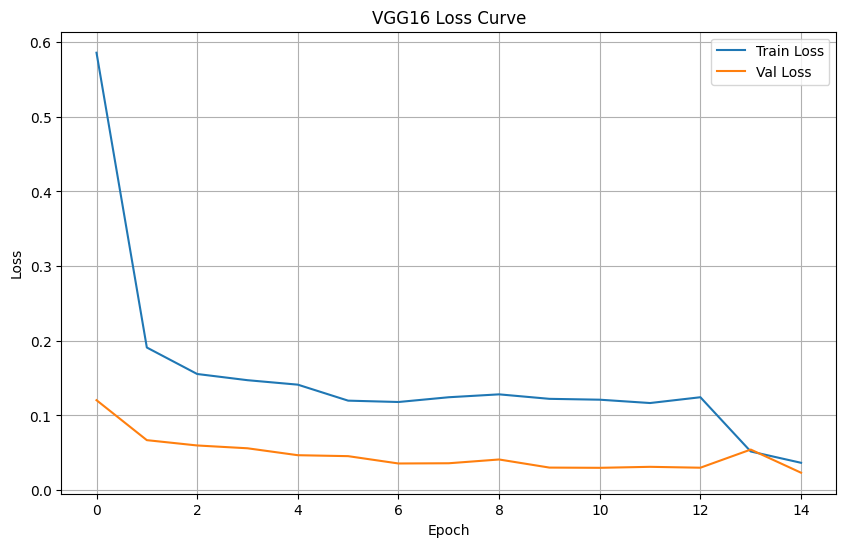

-> VGG16 Loss Grafiği Kaydedildi ✓


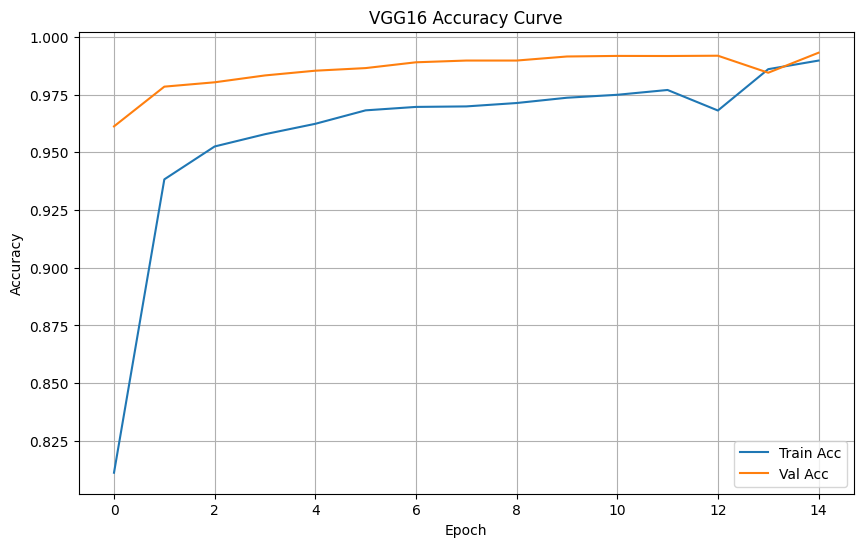

-> VGG16 Accuracy Grafiği Kaydedildi ✓


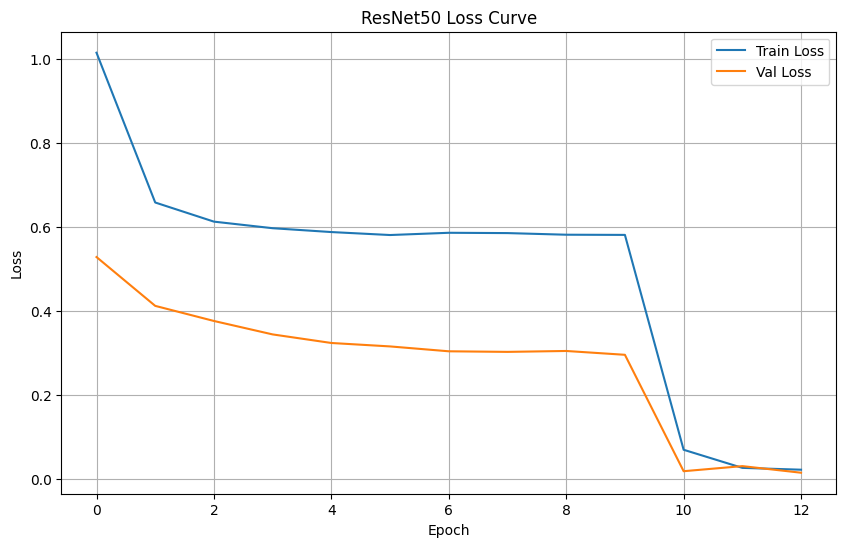

-> ResNet50 Loss Grafiği Kaydedildi ✓


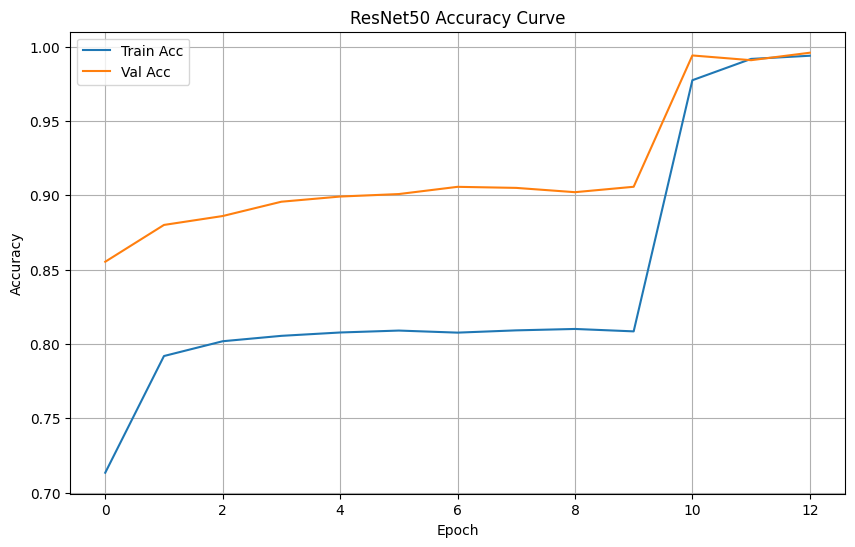

-> ResNet50 Accuracy Grafiği Kaydedildi ✓


In [46]:

vgg_train_loss = vgg16_history_final["train_loss"] + vgg16_history_ft["train_loss"]
vgg_val_loss   = vgg16_history_final["val_loss"]   + vgg16_history_ft["val_loss"]
vgg_train_acc  = vgg16_history_final["train_acc"]  + vgg16_history_ft["train_acc"]
vgg_val_acc    = vgg16_history_final["val_acc"]    + vgg16_history_ft["val_acc"]


res_train_loss = resnet_history_final["train_loss"] + resnet_history_ft["train_loss"]
res_val_loss   = resnet_history_final["val_loss"]   + resnet_history_ft["val_loss"]
res_train_acc  = resnet_history_final["train_acc"]  + resnet_history_ft["train_acc"]
res_val_acc    = resnet_history_final["val_acc"]    + resnet_history_ft["val_acc"]


plt.figure(figsize=(10,6))
plt.plot(vgg_train_loss, label="Train Loss")
plt.plot(vgg_val_loss, label="Val Loss")
plt.title("VGG16 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("VGG16_loss_curve.png", dpi=300)
plt.show()
print("-> VGG16 Loss Grafiği Kaydedildi ✓")


plt.figure(figsize=(10,6))
plt.plot(vgg_train_acc, label="Train Acc")
plt.plot(vgg_val_acc, label="Val Acc")
plt.title("VGG16 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.savefig("VGG16_accuracy_curve.png", dpi=300)
plt.show()
print("-> VGG16 Accuracy Grafiği Kaydedildi ✓")


plt.figure(figsize=(10,6))
plt.plot(res_train_loss, label="Train Loss")
plt.plot(res_val_loss, label="Val Loss")
plt.title("ResNet50 Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("ResNet50_loss_curve.png", dpi=300)
plt.show()
print("-> ResNet50 Loss Grafiği Kaydedildi ✓")


plt.figure(figsize=(10,6))
plt.plot(res_train_acc, label="Train Acc")
plt.plot(res_val_acc, label="Val Acc")
plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.savefig("ResNet50_accuracy_curve.png", dpi=300)
plt.show()
print("-> ResNet50 Accuracy Grafiği Kaydedildi ✓")


In [43]:
cm = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=test_data.classes, yticklabels=test_data.classes)
plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("resnet50_confusion_matrix.png", dpi=300)
plt.close()

print(" Kaydedildi -> resnet50_confusion_matrix.png")


 Kaydedildi -> resnet50_confusion_matrix.png


In [44]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Greens", xticklabels=test_data.classes, yticklabels=test_data.classes)
plt.title("Confusion Matrix - VGG16")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("vgg16_confusion_matrix.png", dpi=300)
plt.close()

print(" Kaydedildi -> vgg16_confusion_matrix.png")


 Kaydedildi -> vgg16_confusion_matrix.png


In [45]:
whos


Variable                Type                Data/Info
-----------------------------------------------------
BATCH_SIZE              int                 64
DATASET_PATH            str                 ./tr_signLanguage_dataset
DataLoader              type                <class 'torch.utils.data.dataloader.DataLoader'>
IMG_SIZE                int                 128
ResNet50_Weights        EnumMeta            <enum 'ResNet50_Weights'>
accuracy_score          function            <function accuracy_score at 0x0000025A8C627F40>
best_val_acc            float               0.8410804020100503
best_vgg                VGG                 VGG(\n  (features): Seque<...>bias=True)\n    )\n  )\n)
build_resnet            function            <function build_resnet at 0x0000025CE96A44C0>
build_vgg               function            <function build_vgg at 0x0000025A8C6DE4D0>
build_vgg_for_final     function            <function build_vgg_for_f<...>al at 0x0000025A8C6DECB0>
cfg                     dict    